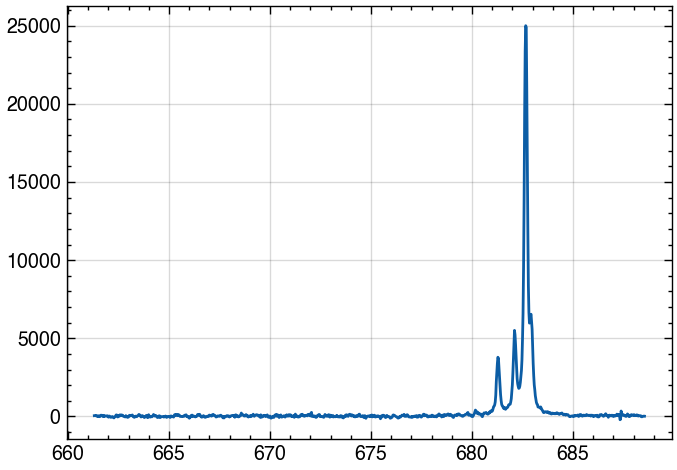

In [22]:
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from toddler.data.spectrum import Spectrum
import wedme

dir_data = Path("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/250107/")
f_pickle = dir_data / "05_04slmH2_06slmCH4_01slmAr_075mbar_roomtemp_idx.pkl"
f_data = dir_data / "05_04slmH2_06slmCH4_01slmAr_075mbar_roomtemp.sif"

s = Spectrum.from_file(f_data, new_axes=True)
s._axis_lambda = 0
info = pickle.load(open(f_pickle, "rb"))

def get_data(data, info, config):
    # Get the keys for the signal and background indices
    sig_key = f"{config}_sig"
    bg_key = f"{config}_bg"

    if not sig_key in info:
        return None, None

    # Get the indices for the signal and background
    sig_ind = info[sig_key]
    bg_ind = info[bg_key]

    # Get the data for the signal and background
    sig_data = data[:, :, sig_ind[0]]
    bg_data = data[:, :, bg_ind[0]]

    sig_data_avg = sig_data.c.bin2((1, 1, sig_data.shape[2]), method="median")
    bg_data_avg = bg_data.c.bin2((1, 1, bg_data.shape[2]), method="median")

    return sig_data_avg, bg_data_avg, sig_data_avg - bg_data_avg


# Load the data of all config
# (sig, bg, sig-bg)
sig_ver, bg_ver, sig_ver_corr = get_data(s, info, 0)
sig_hor, bg_hor, sig_hor_corr = get_data(s, info, 1)

wedme.apply.dev()

plt.figure()
plt.plot(sig_ver_corr.lambdanm, sig_ver_corr.sdata)
plt.show()


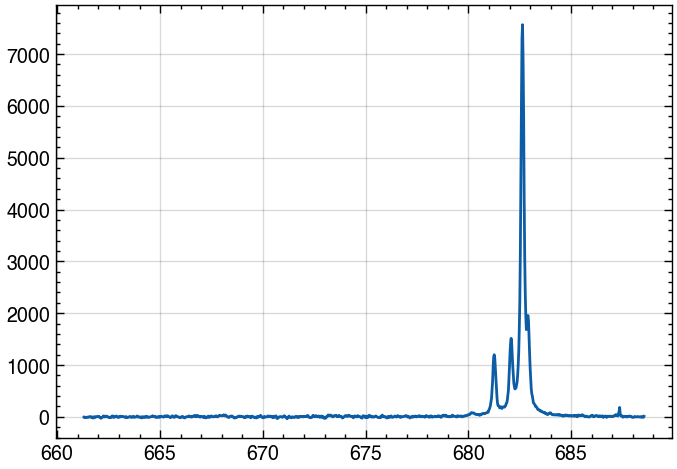

In [3]:
from ramlab.molecules.H2 import H2
import matplotlib.pyplot as plt
import wedme
import numpy as np
from ramlab.molecules.calculated_linelist_molecule import CalculatedLinelistMolecule
from ramlab.simulate import simulate, simulate_raw
import lmfit
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt


from pathlib import Path

f_data = Path("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/250107/04_06slmH2_04slmCH4_01slmAr_100mbar_roomtemp.sif")
# f_data = Path("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/250107/05_04slmH2_06slmCH4_01slmAr_075mbar_roomtemp.sif")
f_pickle = Path("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/250107/05_04slmH2_06slmCH4_01slmAr_075mbar_roomtemp_idx.pkl")



def get_data(data, info, config):
    # Get the keys for the signal and background indices
    sig_key = f"{config}_sig"
    bg_key = f"{config}_bg"

    if not sig_key in info:
        return None, None

    # Get the indices for the signal and background
    sig_ind = info[sig_key]
    bg_ind = info[bg_key]

    # Get the data for the signal and background
    sig_data = data[:, :, sig_ind[0]]
    bg_data = data[:, :, bg_ind[0]]

    sig_data_avg = sig_data.c.median(axis=2)
    bg_data_avg = bg_data.c.median(axis=2)

    return sig_data_avg, bg_data_avg, sig_data_avg - bg_data_avg


def get_polarised_signals(f_data, f_pickle=None):
    if f_pickle is None:
        f_pickle = f_data.with_stem(f_data.stem + "_idx").with_suffix(".pkl")

    # Load pickle file
    info = pickle.load(open(f_pickle, "rb"))

    # Load sif file
    data = Spectrum.from_file(f_data, new_axes=True)
    data._axis_lambda = 0

    # Load the data of all config
    # (sig, bg, sig-bg)
    sig_ver, bg_ver, sig_ver_corr = get_data(data, info, 0)
    sig_hor, bg_hor, sig_hor_corr = get_data(data, info, 1)

    return sig_ver_corr, sig_hor_corr

ver, hor = get_polarised_signals(f_data)

plt.plot(ver.lambdanm, ver.sdata)

Generating linelist file...
Calculating cross-section
Calculating cross-section


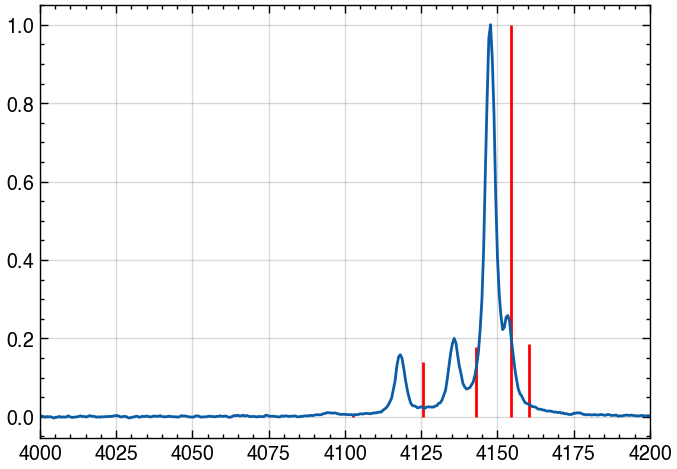

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 132
    # data points      = 1024
    # variables        = 3
    chi-square         = 4.5094e-06
    reduced chi-square = 4.4167e-09
    Akaike info crit   = -19696.5877
    Bayesian info crit = -19681.7933
[[Variables]]
    A:                    1 (fixed)
    T:                    300 (fixed)
    w_g:                  0.97701420 +/- 0.01293407 (1.32%) (init = 1)
    w_l:                  1.23825060 +/- 0.01544984 (1.25%) (init = 1)
    lambda_correction_0:  0.32508194 +/- 1.4743e-04 (0.05%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(w_g, w_l)                 = -0.9723
    C(w_l, lambda_correction_0) = -0.1340


In [19]:
from lmfit import minimize, Parameters, fit_report
from ramlab.simulate.linespreadfunction.functions import gaussian, voigt, lorentzian, rect, martijnian

from ttictoc import tic,toc


from ramlab.fit.modifiers import *
from ramlab.molecules.polarisation import Polarisation


M = CalculatedLinelistMolecule(H2)
transitions = M.get_all_transitions(laser_wavelength=532e-9, force_recalculate=True)
transitions = transitions[transitions.dv == 1]
# transitions = transitions[transitions.dJ == 0]
transitions = transitions[transitions.initial_J < 5]
transitions = transitions[transitions.crosssection != np.nan]

I_const_par = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PARALLEL)
I_const_per = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PERPENDICULAR)
I_var = M.get_intensity_variable(transitions, T=300)

I = (I_const_par + I_const_per) * I_var
I /= np.nanmax(I)
dnu = M.dE(transitions)

plt.vlines(dnu, 0, I, 'r')
plt.plot(ver.dnu()/1e2, ver.c.normalize(axis=0).sdata)
plt.xlim(4000, 4200)
plt.show()


fitParameters = Parameters()
fitParameters.add("A", value=1, vary=False)
fitParameters.add("T", value=300, vary=False)
fitParameters.add("w_g", value=1, min=0, vary=True)
fitParameters.add("w_l", value=1, min=0, vary=True)

wavelengthCorrection = WavelengthAxisCorrection(0)
wavelengthCorrection.add_parameters(fitParameters)

def spectral_fit_residuals(pars: Parameters, meas, I_const_per, I_const_par, test=False):
    tic()
    A = pars['A']
    T = pars['T']
    w_g = pars['w_g']
    w_l = pars['w_l']

    meas = MeasurementSpectrum(meas)
    meas = wavelengthCorrection.modify(meas, pars)

    meas = meas.data
    dnu_meas = meas.dnu()/1e2, 
    I_meas = meas.c.normalize(axis=0).sdata


    I_var = M.get_intensity_variable(transitions, T=T)
    I_stick_sim = (I_const_per) * I_var
    # I_stick_sim = (I_const_per + I_const_par) * I_var
    I_stick_sim /= np.nanmax(I_stick_sim)

    dnu_stick = transitions.vacuum_wavenumber

    I_sim_broad = simulate_raw(dnu_meas, dnu_stick, I_stick_sim, w_g, w_l)
    I_sim_broad *= A / np.nanmax(I_sim_broad)

    # print(f"Execution time: {toc()*1e3:.0f}ms")

    if test is True:
        return I_sim_broad

    return (I_sim_broad - I_meas)**2

out = minimize(spectral_fit_residuals, fitParameters, args=(ver.c.normalize(axis=0), I_const_per, I_const_par))
spectral_fit_residuals(fitParameters, ver.c.normalize(axis=0), I_const_per, I_const_par, test=True)

print(fit_report(out))

(4000.0, 4200.0)

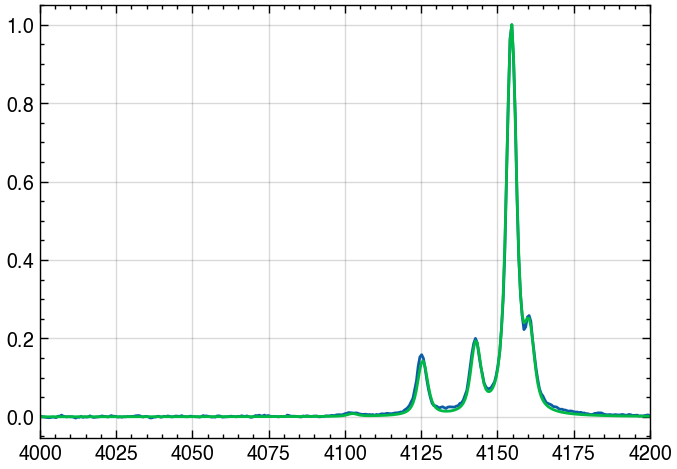

In [21]:
ver2 = wavelengthCorrection.modify(MeasurementSpectrum(ver.c), out.params).data

plt.figure()
plt.plot(ver2.dnu()/1e2, ver2.c.normalize(axis=0).sdata)
plt.plot(ver2.dnu()/1e2, spectral_fit_residuals(out.params, ver.c.normalize(axis=0), I_const_per, I_const_par, test=True))
plt.xlim(4000, 4200)